# Financial Analysis

This notebook adds a financial overlay to the Experience-Centered AI framework.

Financial metrics are not included in the Experience AI Score. They are used separately to evaluate whether high-scoring companies also show strong business performance.

In [7]:
# =====================================================
# Experience-Centered AI Analysis
# Notebook 4: Financial Analysis
# =====================================================

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

DATA_DIR = project_root / "data" / "raw"
OUTPUT_DIR = project_root / "data" / "outputs"
CHART_DIR = project_root / "charts"

OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

print("Project root:", project_root)

Project root: c:\Users\Owner\OneDrive\Desktop\experience-centered-ai


In [8]:
# Load Experience AI scores and company ticker list

scores_df = pd.read_csv(DATA_DIR / "scoring.csv")
financial_seed_df = pd.read_csv(DATA_DIR / "financial_metrics.csv")

# Remove blank ticker rows if they exist
financial_seed_df = financial_seed_df.dropna(subset=["ticker"])

scores_df.head()

,company_id,company,industry,experience_intensity,ai_enhancement,repeat_usage,agency_preservation,revenue_capture,network_effects,experience_ai_score
0,1,Peloton,Fitness,10,9,8,9,8,6,8.65
1,2,Planet Fitness,Fitness,7,6,7,8,8,4,6.75
2,3,Duolingo,Education,9,10,10,9,9,7,9.20
3,4,Coursera,Education,8,8,7,8,7,5,7.40
4,5,Roblox,Gaming,10,9,10,10,9,10,9.70


In [9]:
# Pull current financial metrics from Yahoo Finance

records = []

for ticker in financial_seed_df["ticker"]:

    try:
        stock = yf.Ticker(ticker)
        info = stock.info

        records.append({
            "ticker": ticker,
            "market_cap_bil": info.get("marketCap", np.nan) / 1_000_000_000,
            "revenue_growth_pct": info.get("revenueGrowth", np.nan) * 100,
            "gross_margin_pct": info.get("grossMargins", np.nan) * 100,
            "operating_margin_pct": info.get("operatingMargins", np.nan) * 100
        })

        print(f"Loaded {ticker}")

    except Exception as e:
        print(f"Failed {ticker}: {e}")

pulled_financials = pd.DataFrame(records)

pulled_financials.head()

Loaded PTON
Loaded PLNT
Loaded DUOL
Loaded COUR
Loaded RBLX
Loaded EA
Loaded INTU
Loaded SOFI
Loaded ABNB
Loaded BKNG
Loaded NFLX
Loaded SPOT
Loaded HFG.DE
Loaded SG
Loaded MTCH
Loaded BMBL


,ticker,market_cap_bil,revenue_growth_pct,gross_margin_pct,operating_margin_pct
0,PTON,2.351146,1.1,51.959000,9.510000
1,PLNT,4.056348,19.7,58.792996,32.513002
2,DUOL,5.928974,26.5,72.665000,15.369001
3,COUR,1.520564,9.1,54.800000,-12.928000
4,RBLX,33.844316,39.3,24.100000,-16.436000


In [10]:
# Merge pulled financial metrics back to company names

financial_df = financial_seed_df[["company", "ticker"]].merge(
    pulled_financials,
    on="ticker",
    how="left"
)

financial_df

,company,ticker,market_cap_bil,revenue_growth_pct,gross_margin_pct,operating_margin_pct
0,Peloton,PTON,2.351146,1.1,51.959000,9.510000
1,Planet Fitness,PLNT,4.056348,19.7,58.792996,32.513002
2,Duolingo,DUOL,5.928974,26.5,72.665000,15.369001
3,Coursera,COUR,1.520564,9.1,54.800000,-12.928000
4,Roblox,RBLX,33.844316,39.3,24.100000,-16.436000
5,Electronic Arts,EA,50.895028,11.9,78.967005,24.009001
6,Intuit,INTU,70.509625,10.4,80.793000,46.974000
7,SoFi,SOFI,21.934877,42.5,83.507000,18.283000
8,Airbnb,ABNB,82.609947,17.9,82.913000,3.211000
9,Booking Holdings,BKNG,130.001363,16.2,86.987000,25.035998


In [11]:
# Save populated financial dataset

financial_df.to_csv(
    DATA_DIR / "financial_metrics.csv",
    index=False
)

print("Updated financial_metrics.csv saved.")

Updated financial_metrics.csv saved.


In [12]:
# Confirm no companies are missing financial data

missing_financials = merged_df[
    merged_df[
        [
            "market_cap_bil",
            "revenue_growth_pct",
            "gross_margin_pct",
            "operating_margin_pct"
        ]
    ].isna().any(axis=1)
]

missing_financials[["company"]]

NameError: name 'merged_df' is not defined

In [ ]:
# Compare Experience AI scores against financial metrics

merged_df = scores_df.merge(
    financial_df,
    on="company",
    how="left"
)

merged_df.head()

,company_id,company,industry,experience_intensity,ai_enhancement,repeat_usage,agency_preservation,revenue_capture,network_effects,experience_ai_score,ticker,market_cap_bil,revenue_growth_pct,gross_margin_pct,operating_margin_pct
0,1,Peloton,Fitness,10,9,8,9,8,6,8.65,PTON,2.351146,1.1,51.959000,9.510000
1,2,Planet Fitness,Fitness,7,6,7,8,8,4,6.75,PLNT,4.056348,19.7,58.792996,32.513002
2,3,Duolingo,Education,9,10,10,9,9,7,9.20,DUOL,5.928974,26.5,72.665000,15.369001
3,4,Coursera,Education,8,8,7,8,7,5,7.40,COUR,1.520564,9.1,54.800000,-12.928000
4,5,Roblox,Gaming,10,9,10,10,9,10,9.70,RBLX,33.844316,39.3,24.100000,-16.436000


## Financial Overlay

The financial overlay compares each company's Experience AI Score against selected business performance metrics.

This allows the analysis to distinguish between strategic thesis alignment and current financial strength.

In [ ]:
financial_overlay = (
    merged_df[
        [
            "company",
            "industry",
            "experience_ai_score",
            "market_cap_bil",
            "revenue_growth_pct",
            "gross_margin_pct",
            "operating_margin_pct"
        ]
    ]
    .sort_values("experience_ai_score", ascending=False)
    .reset_index(drop=True)
)

financial_overlay

,company,industry,experience_ai_score,market_cap_bil,revenue_growth_pct,gross_margin_pct,operating_margin_pct
0,Roblox,Gaming,9.70,33.844316,39.3,24.100000,-16.436000
1,Duolingo,Education,9.20,5.928974,26.5,72.665000,15.369001
2,Match Group,Dating,8.85,8.220313,3.9,73.877996,27.365000
3,Peloton,Fitness,8.65,2.351146,1.1,51.959000,9.510000
4,Bumble,Dating,8.65,0.423186,-14.1,71.884000,31.480000
5,Spotify,Entertainment,8.35,94.449517,8.2,32.318002,15.773000
6,Electronic Arts,Gaming,8.25,50.895028,11.9,78.967005,24.009001
7,Netlix,Entertainment,7.95,306.883002,16.2,49.029000,32.303002
8,HelloFresh,Food/Cooking,7.75,0.564051,-13.2,61.092997,-3.534000
9,Airbnb,Travel,7.70,82.609947,17.9,82.913000,3.211000


In [ ]:
# Calculate correlations between Experience AI Score and financial metrics

correlation_matrix = merged_df[
    [
        "experience_ai_score",
        "market_cap_bil",
        "revenue_growth_pct",
        "gross_margin_pct",
        "operating_margin_pct"
    ]
].corr()

correlation_matrix

,experience_ai_score,market_cap_bil,revenue_growth_pct,gross_margin_pct,operating_margin_pct
experience_ai_score,1.000000,-0.082841,0.032063,-0.142989,-0.060994
market_cap_bil,-0.082841,1.000000,0.179312,0.013233,0.346634
revenue_growth_pct,0.032063,0.179312,1.000000,0.097550,-0.005015
gross_margin_pct,-0.142989,0.013233,0.097550,1.000000,0.607604
operating_margin_pct,-0.060994,0.346634,-0.005015,0.607604,1.000000


## Correlation Analysis

The correlation matrix provides a simple way to evaluate whether higher Experience AI Scores are associated with stronger financial metrics.

Because the sample size is small, these correlations should be interpreted as directional rather than statistically definitive.

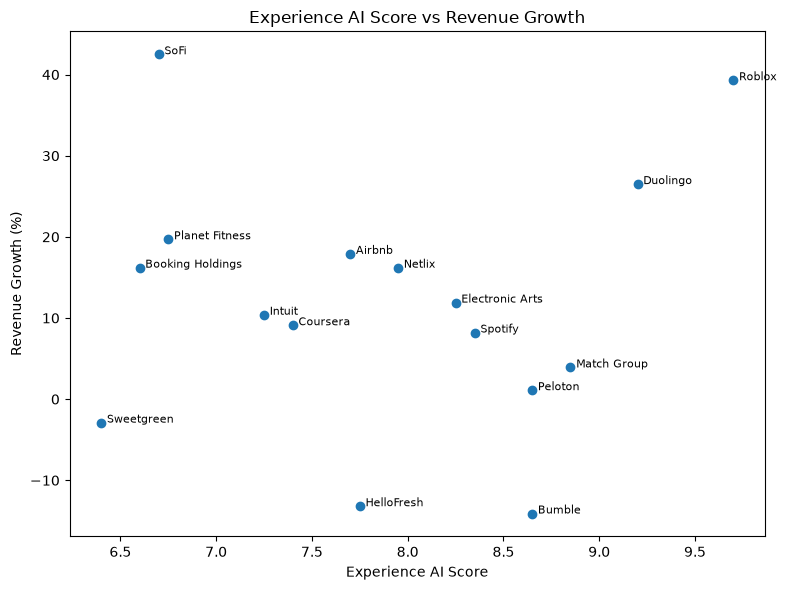

In [ ]:
# Scatterplot: Experience AI Score vs Revenue Growth

plt.figure(figsize=(8, 6))

plt.scatter(
    merged_df["experience_ai_score"],
    merged_df["revenue_growth_pct"]
)

for _, row in merged_df.iterrows():
    plt.text(
        row["experience_ai_score"] + 0.03,
        row["revenue_growth_pct"],
        row["company"],
        fontsize=8
    )

plt.xlabel("Experience AI Score")
plt.ylabel("Revenue Growth (%)")
plt.title("Experience AI Score vs Revenue Growth")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "score_vs_revenue_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

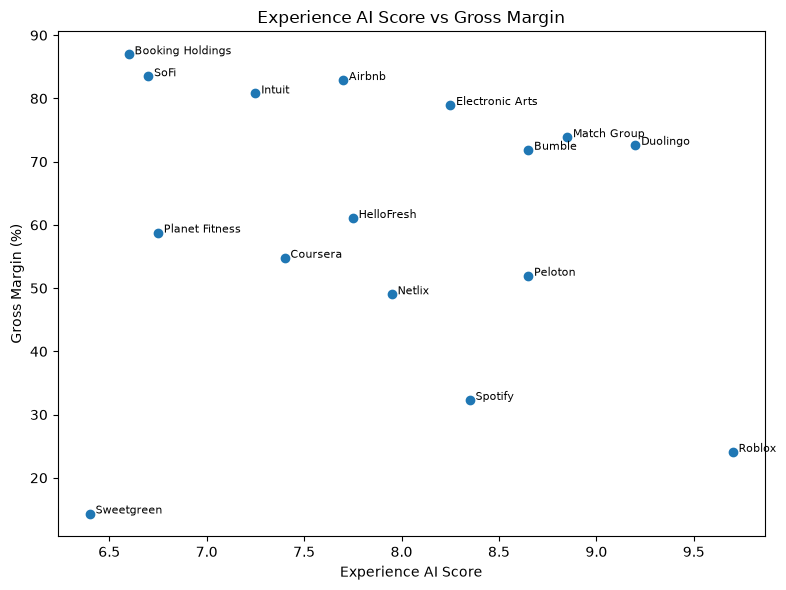

In [ ]:
# Scatterplot: Experience AI Score vs Gross Margin

plt.figure(figsize=(8, 6))

plt.scatter(
    merged_df["experience_ai_score"],
    merged_df["gross_margin_pct"]
)

for _, row in merged_df.iterrows():
    plt.text(
        row["experience_ai_score"] + 0.03,
        row["gross_margin_pct"],
        row["company"],
        fontsize=8
    )

plt.xlabel("Experience AI Score")
plt.ylabel("Gross Margin (%)")
plt.title("Experience AI Score vs Gross Margin")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "score_vs_gross_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

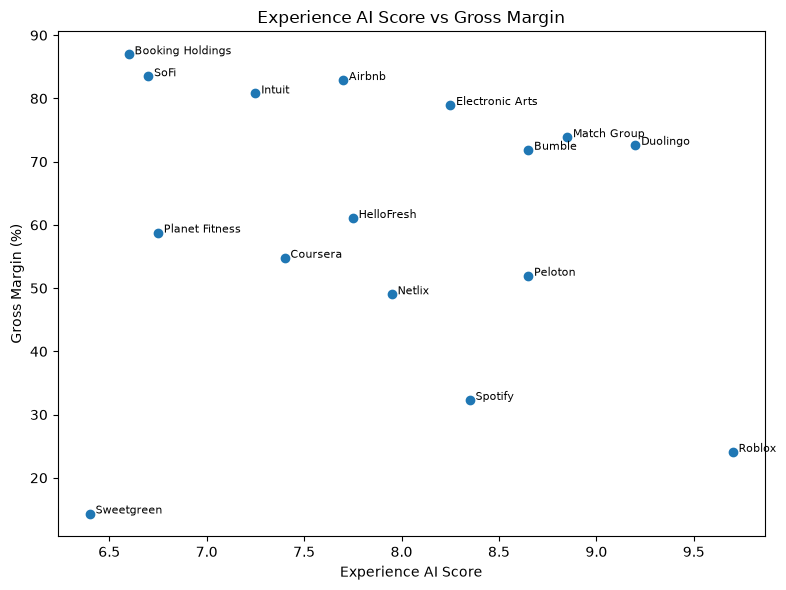

In [ ]:
# Scatterplot: Experience AI Score vs Gross Margin

plt.figure(figsize=(8, 6))

plt.scatter(
    merged_df["experience_ai_score"],
    merged_df["gross_margin_pct"]
)

for _, row in merged_df.iterrows():
    plt.text(
        row["experience_ai_score"] + 0.03,
        row["gross_margin_pct"],
        row["company"],
        fontsize=8
    )

plt.xlabel("Experience AI Score")
plt.ylabel("Gross Margin (%)")
plt.title("Experience AI Score vs Gross Margin")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "score_vs_gross_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Save merged financial analysis dataset

financial_overlay.to_csv(
    OUTPUT_DIR / "financial_overlay.csv",
    index=False
)

correlation_matrix.to_csv(
    OUTPUT_DIR / "financial_correlation_matrix.csv"
)

print("Financial analysis outputs saved.")

Financial analysis outputs saved.


# Financial Findings

The financial overlay was designed to evaluate whether companies that score highly under the Experience-Centered AI framework also demonstrate strong traditional business performance.

The analysis found that Experience AI Scores exhibited minimal correlation with market capitalization, revenue growth, gross margin, and operating margin within the sample. Correlation coefficients between the framework score and financial metrics were all close to zero, suggesting that the framework is measuring a strategic dimension distinct from conventional financial performance indicators.

Several high-scoring companies nevertheless demonstrated strong business results. Roblox achieved the highest overall Experience AI Score while also exhibiting the strongest revenue growth rate among the analyzed companies. Duolingo similarly combined a high framework score with strong growth and attractive margins, making it one of the clearest examples of alignment between the Experience-Centered AI thesis and current business success.

At the same time, the analysis identified multiple counterexamples. SoFi displayed one of the strongest revenue growth rates in the sample despite receiving a more moderate Experience AI Score. Booking Holdings achieved exceptional profitability metrics while ranking lower on the framework. These cases suggest that strong financial performance can emerge through business models that are not necessarily optimized for participation, agency preservation, mastery, or engagement.

The results therefore indicate that the Experience-Centered AI framework is not simply a proxy for growth investing, profitability, or company size. Instead, it appears to capture a distinct hypothesis regarding how AI may create value by enhancing human participation rather than replacing it.

From an investment perspective, the framework may be most useful as a complementary lens rather than a replacement for traditional financial analysis. Financial metrics evaluate current business performance, while the Experience-Centered AI Score attempts to evaluate strategic positioning within a future AI-driven economy.

Overall, the financial analysis provides preliminary evidence that the framework identifies characteristics that are largely independent of current financial outcomes. Further research using larger company samples, additional industries, and longer-term performance data would be required to determine whether strong Experience AI alignment ultimately translates into superior long-term shareholder value.